In [73]:
import importlib
import perceptron_architecture
importlib.reload(perceptron_architecture)
from perceptron_architecture import *

In [63]:
swiss_roll = get_swiss_roll(5000, 0.3)

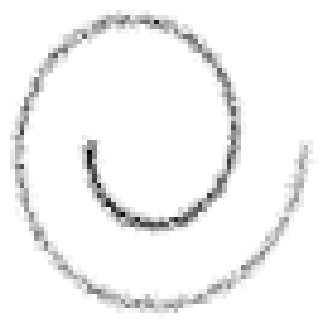

In [64]:
swiss = plot_swiss_roll_2D(swiss_roll, 64)

In [65]:
flattened_roll = swiss.view(-1)

In [67]:
print(flattened_roll)
print(flattened_roll.shape)

tensor([1., 1., 1.,  ..., 1., 1., 1.])
torch.Size([4096])


In [70]:
gaussian_matrix = get_gaussian_matrix(flattened_roll.numel(), flattened_roll.numel(), 0, 1)

In [71]:
print(gaussian_matrix)

tensor([[ 0.1165,  0.7513, -0.2145,  ..., -1.8625, -0.3608,  2.2322],
        [ 0.4805, -0.1482,  0.6184,  ..., -1.7384, -1.3048,  0.4780],
        [ 0.3991, -0.0493, -0.1210,  ..., -0.8978, -0.0755,  0.1960],
        ...,
        [-0.0035, -1.0228,  0.0531,  ..., -1.8574, -0.6427,  0.6069],
        [ 0.5433,  1.2920, -3.0772,  ..., -0.5495, -0.0894, -0.1124],
        [ 0.0338,  0.7636,  0.1672,  ..., -1.5765,  0.5422, -0.7190]])


In [72]:
# now we will multiply the swiss roll by the random matrix to see what happens
output_tensor = gaussian_matrix @ flattened_roll

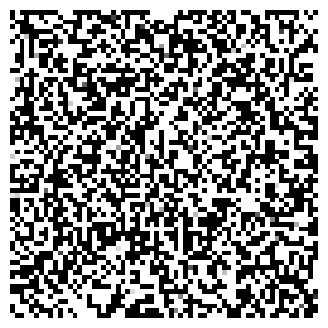

In [75]:
see_grayscale(output_tensor, image_size = 64)

In [76]:
# the important part about flow matching is that we have to push our velocity field through an ODE or SDE time stepper.
# we consider our random gaussian matrix to be the velocity field and we will push through an ODE Euler time stepper.
# one thing to note is that our matrix has no sense of time, so for any time step, we act as if we are on the same time.
def euler_random_matrix(x0, W, n_steps = 100):
    """
    input: x0 is the starting point (flattened)
    W is the gaussian matrix
    n_steps is the amount of steps we would like to take
    """
    dt = 1.0 / n_steps
    x = x0.clone()

    for step in range(n_steps):
        t = step * dt
        v = W @ x
        x = x + dt * v
    
    return x

In [ ]:
push_output = euler_random_matrix(flattened_roll, gaussian_matrix, n_steps=100)

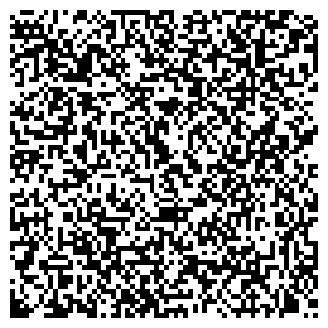

tensor(-2.1277e+21) tensor(2.3852e+21) tensor(5.9487e+20)


In [81]:
# note that the see_grayscale function expects the values at the end to be within [-1,1] but they are not because we have
# our random gaussian matrix. Hence we will see something which looks like a QR code of black and white because the values are spread out outside
# the range of [-1,1] and clipped back into it.

see_grayscale(push_output, image_size=64)
print(push_output.min(), push_output.max(), push_output.std())

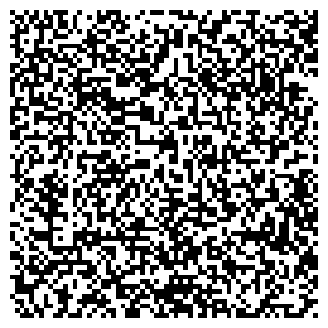

tensor(-1141620.) tensor(1521953.5000) tensor(334371.7500)


In [82]:
# let us consider only a handful of time steps
push_output = euler_random_matrix(flattened_roll, gaussian_matrix, n_steps=5)
see_grayscale(push_output, image_size=64)
print(push_output.min(), push_output.max(), push_output.std())

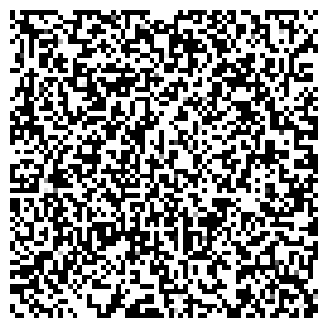

tensor(-189.6945) tensor(223.9533) tensor(59.3872)


In [ ]:
# then we can visualize with one time step
push_output = euler_random_matrix(flattened_roll, gaussian_matrix, n_steps=1)
see_grayscale(push_output, image_size=64)
print(push_output.min(), push_output.max(), push_output.std())

We takeaway that when we use a random gaussian matrix, the output will look random as well and will explode in value for more time steps that we have. When we train on MLP or UNet we dont really see this as an issue, which we can think because of the activation functions and the learning penalizing this behavior. With no learning, and just a random gaussian matrix, the time stepping will explode for lots of time steps because thre is no regularization in the model. This shows that we need some type of activation layer to circumvent this problem.

Now we will consider what happens when we have less points in our starting x0.

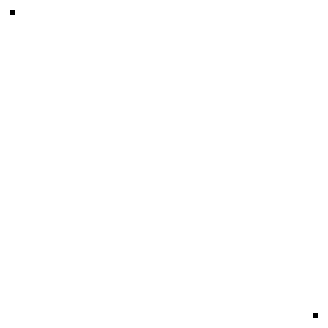

In [97]:
swiss_roll = get_swiss_roll(2, 0.1)
X = plot_swiss_roll_2D(swiss_roll, image_size = 64)

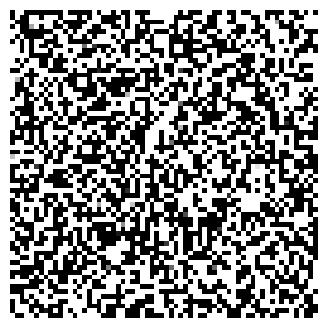

tensor(-218.9848) tensor(230.2629) tensor(63.2230)


In [98]:
push_output = euler_random_matrix(X.view(-1), gaussian_matrix, n_steps=1)
see_grayscale(push_output, image_size=64)
print(push_output.min(), push_output.max(), push_output.std())

From this we still see an explosion of randomness which makes us realize that it is vital to have a learned velocity field for flow matching to work.